In [1]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sps

import pyGameWorld as pgw

import sys
sys.path.append("../../models/")

plt.style.use("../../plotStyle.mplstyle")

In [2]:
memory = pd.read_csv("memory.csv")
memory["correct_conf"] = memory.apply(lambda x: 100 - x.response if x.answer == 0 else x.response, axis=1)
memory["obj_cond"] = pd.Categorical(memory.obj_cond, categories=["col_early", "col_late", "maybecol", "nocol"], ordered=True)
memory["correct"] = memory.apply(lambda x: 1.0 if x.correct_conf > 50 else 0.0, axis=1)
# memory["correct_conf_z"] = memory.groupby("pid")["correct_conf"].transform(lambda x: (x - x.mean()) / x.std())

/var/folders/kq/pqdcplq11j1dmpjqvs4428z00000gn/T/ipykernel_89064/2509694455.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  p.set_xticklabels(["Early collision", "Late collision", "Maybe collision", "No collision"], rotation=45)


<Axes: ylabel='Recall'>

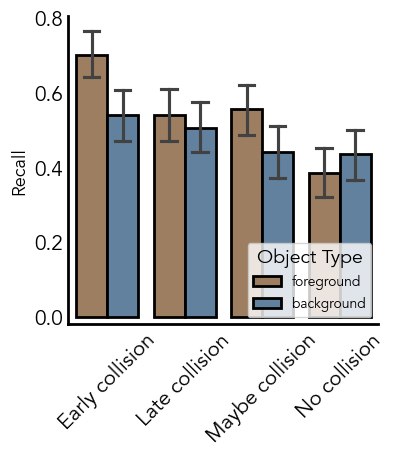

In [3]:
import matplotlib.colors as mcolors
from matplotlib.colors import ColorConverter

colors = ["#A87E57", "#5781A8"]
colors = [mcolors.to_rgba(c, alpha=0.01) for c in colors]

with plt.rc_context({"legend.fontsize": 10}):
    fig, ax = plt.subplots(figsize=(4,4))
    p = sns.barplot(memory, x="obj_cond", y="correct", hue="bg_cond", palette=colors, ec="black", lw=2, capsize=0.4)
    # sns.swarmplot(memory, x="obj_cond", y="correct_conf", hue="bg_cond", palette=colors, dodge=True, size=3, ax=ax, edgecolor="black", linewidth=0.5)
    ax.set_ylim(-0.02)
    ax.set_ylabel("Recall", fontsize=13)
    ax.set_xlabel("")
    plt.legend(loc="lower right").set(title="Object Type")
    p.set_xticklabels(["Early collision", "Late collision", "Maybe collision", "No collision"], rotation=45)
fig.savefig("../../figures/foreground_background_memory.pdf", bbox_inches="tight")
p

In [4]:
collisions = pd.read_csv("../exp_likelihood/collision_judgments_cleaned.csv")
collisions["cond"] = collisions["cond"].apply(lambda x: x[:-10])
tmp = collisions.groupby(["cond", "world"])[["response", "response_z"]].mean().reset_index()
tmp = tmp.rename({"response": "collision_likelihood", "response_z": "collision_likelihood_z"}, axis=1)
fulldata = pd.merge(memory.groupby(["world", "obj_cond", "bg_cond", "obj_name"], as_index=False)[["correct_conf", "correct"]].mean().dropna(), tmp, left_on=["world", "obj_cond"], right_on=["world", "cond"])

In [5]:
memory.groupby(["world", "obj_cond", "bg_cond", "obj_name"]).correct_conf.mean().dropna()

world                     obj_cond   bg_cond     obj_name    
hh_hl_unlink_plinko_0105  col_early  background  topbump_1       61.000000
                                     foreground  topbump_1       73.352941
                          maybecol   background  bottombump_0    54.000000
                                     foreground  bottombump_0    58.607143
                          nocol      background  topbump_4       56.500000
                                                                   ...    
lh_ll_unlink_plinko_0217  col_early  foreground  topbump_4       73.947368
                          col_late   background  bottombump_1    49.166667
                                     foreground  bottombump_1    53.370370
                          nocol      background  bottombump_0    49.125000
                                     foreground  bottombump_0    50.090909
Name: correct_conf, Length: 96, dtype: float64

In [6]:
worlds = {
    w: pgw.loadFromDict(
        json.load(open(f"../../experiments/assets/exp_likelihood/targets/{w}/{w}.json"))["world"]
    )
    for w in memory.world.unique()
}
noisysim_pars = {
    "noise_position_static": 0.0,
    "noise_position_moving": 5.0,
    "noise_collision_direction": 0.8,
    "noise_collision_elasticity": 0.6,
    "noise_gravity": 0.0,
}

In [7]:
process_model_predictions = pd.read_csv("../../models/jit_predictions.csv")
process_model_predictions.rename(columns={"object": "obj_name"}, inplace=True)
joint_predictions = pd.merge(fulldata[["collision_likelihood", "world", "obj_name", "correct_conf", "obj_cond", "bg_cond", "correct"]], process_model_predictions, on=["world", "obj_name"], how="left")

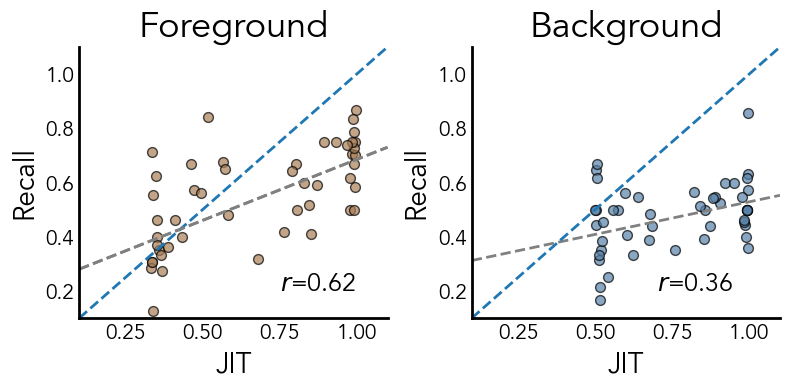

In [8]:
colors = ["#A87E57", "#5781A8"]

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
tmp = joint_predictions[joint_predictions.bg_cond == "foreground"].groupby(["world", "obj_cond"])[["model_p", "correct"]].mean().reset_index()
tmp["model_p"] = tmp["model_p"] * 0.667 + 0.333
plt.scatter("model_p", "correct", data=tmp, color=colors[0],
            s=50, lw=1, ec="k", alpha=0.7)
lims = (0.1, 1.1)
b, a, *_ = sps.linregress(tmp.model_p, y=tmp.correct)
plt.plot([lims[0], lims[1]], [a, a + lims[1] * b], "--", lw=2, c="gray")
plt.plot([lims[0], lims[1]], [lims[0], lims[1]], "--", c="tab:blue", lw=2)
plt.xlim(lims)
plt.ylim(lims)

plt.plot([lims[0], lims[1]], [a, a + lims[1] * b], "--", lw=2, c="gray")
plt.ylabel("Recall")
plt.xlabel("JIT")
plt.title("Foreground")
# plt.legend([], loc="lower right", title=f"$R^2$={tmp.model_p.corr(tmp.correct)**2:.2f}")
plt.text(0.75, 0.2, f"$r$={tmp.model_p.corr(tmp.correct):.2f}", fontsize=18, fontweight="bold")

plt.subplot(1, 2, 2)
tmp = joint_predictions[joint_predictions.bg_cond == "background"].groupby(["world", "obj_cond"])[["model_p", "correct"]].mean().reset_index()
tmp["model_p"] = tmp["model_p"] * 0.5 + 0.5
plt.scatter("model_p", "correct", data=tmp, color=colors[1],
            s=50, lw=1, ec="k", alpha=0.7)

lims = (0.1, 1.1)
b, a, *_ = sps.linregress(tmp.model_p, y=tmp.correct)
plt.plot([lims[0], lims[1]], [a, a + lims[1] * b], "--", lw=2, c="gray")
plt.plot([lims[0], lims[1]], [lims[0], lims[1]], "--", c="tab:blue", lw=2)
plt.xlim(lims)
plt.ylim(lims)
# plt.legend([], loc="lower right", title=f"$R^2$={tmp.model_p.corr(tmp.correct)**2:.2f}")

plt.xlabel("JIT")
plt.ylabel("Recall")
plt.title("Background")
# plt.legend([], loc="lower right", title=f"$R^2$={tmp.model_p.corr(tmp.correct)**2:.2f}")
plt.text(0.7, 0.2, f"$r$={tmp.model_p.corr(tmp.correct):.2f}", fontsize=18, fontweight="bold")
plt.tight_layout()

plt.savefig("../../figures/model_memory_collision_fgbg.pdf")
plt.show()

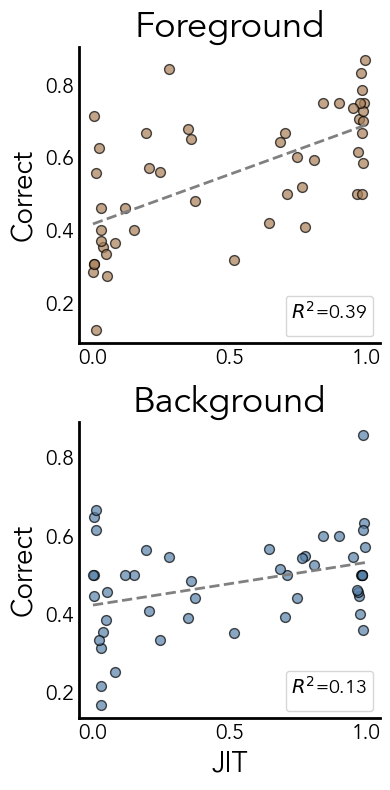

In [9]:
colors = ["#A87E57", "#5781A8"]

plt.figure(figsize=(4, 8))
plt.subplot(2, 1, 1)
tmp = joint_predictions[joint_predictions.bg_cond == "foreground"]
plt.scatter("model_p", "correct", data=tmp, color=colors[0],
            s=50, lw=1, ec="k", alpha=0.7)
b, a, *_ = sps.linregress(tmp.model_p, y=tmp.correct)
plt.plot([0, 1], [a, a + 1 * b], "--", lw=2, c="gray")
plt.ylabel("Correct")
plt.title("Foreground")
plt.legend([], loc="lower right", title=f"$R^2$={tmp.model_p.corr(tmp.correct)**2:.2f}")

plt.subplot(2, 1, 2)
tmp = joint_predictions[joint_predictions.bg_cond == "background"]
plt.scatter("model_p", "correct", data=tmp, color=colors[1],
            s=50, lw=1, ec="k", alpha=0.7)
b, a, *_ = sps.linregress(tmp.model_p, y=tmp.correct)
plt.plot([0, 1], [a, a + 1 * b], "--", lw=2, c="gray")
plt.legend([], loc="lower right", title=f"$R^2$={tmp.model_p.corr(tmp.correct)**2:.2f}")

plt.xlabel("JIT")
plt.ylabel("Correct")
plt.title("Background")
plt.legend([], loc="lower right", title=f"$R^2$={tmp.model_p.corr(tmp.correct)**2:.2f}")
plt.tight_layout()

plt.show()

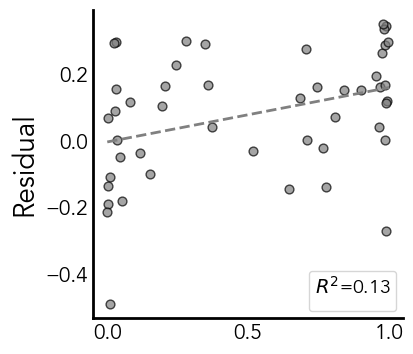

In [10]:
tmp = joint_predictions.pivot(
    index=["world", "obj_name", "obj_cond"],
    columns="bg_cond",
    values=["correct", "model_p"]
).reset_index()
tmp["human_diff"] = tmp["correct", "foreground"] - tmp["correct", "background"]
plt.figure(figsize=(4, 4))
plt.scatter(tmp["model_p", "foreground"], tmp["human_diff"], s=40, lw=1, ec="k", alpha=0.7, c="tab:gray")
a, b = np.polyfit(tmp["model_p", "foreground"], tmp["human_diff"], deg=1)
plt.plot([0, 1], [b, b + a], "--", lw=2, c="gray")
plt.legend([], loc="lower right", title=f"$R^2$={tmp['model_p', 'foreground'].corr(tmp['human_diff'])**2:.2f}")
plt.ylabel("Residual")
plt.show()

In [11]:
%load_ext rpy2.ipython

regression_data = pd.merge(memory[["world", "obj_cond", "bg_cond", "obj_name", "correct_conf", "correct", "pid"]], process_model_predictions[["world", "obj_name", "model_p"]], on=["world", "obj_name"])

In [12]:
%%R -i regression_data
library(lme4)
model = glmer("correct ~ 1 + (1 | pid) + bg_cond", data=regression_data, family=binomial)
basemodel = glmer("correct ~ 1 + (1 | pid)", data=regression_data, family=binomial)

anova(basemodel, model)

Data: regression_data
Models:
basemodel: correct ~ 1 + (1 | pid)
model: correct ~ 1 + (1 | pid) + bg_cond
          npar    AIC    BIC  logLik deviance  Chisq Df Pr(>Chisq)   
basemodel    2 2194.2 2204.9 -1095.1   2190.2                        
model        3 2189.0 2205.1 -1091.5   2183.0 7.1947  1   0.007312 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


Loading required package: Matrix


In [13]:
memory.columns

Index(['trial', 'rt', 'response', 'baseimg0', 'baseimg1', 'recording0',
       'recording1', 'obj_name', 'worldtype', 'sim_x_result', 'obj_cond',
       'bg_cond', 'world', 'cond', 'count', 'img0', 'img1',
       'background_color_idx', 'background_color', 'pid', 'answer', 'img',
       'correct_conf', 'correct'],
      dtype='object')

In [18]:
from scipy.stats import ttest_1samp

_tmp = joint_predictions[["world", "obj_cond", "obj_name", "bg_cond", "correct"]]
_merged = pd.merge(_tmp.query("bg_cond == 'foreground'"), _tmp.query("bg_cond == 'background'"), on=["world", "obj_cond", "obj_name"], suffixes=("_fg", "_bg"))

col_earlys = _merged.query("obj_cond == 'col_early'")
col_lates = _merged.query("obj_cond == 'col_late'")
maybecols = _merged.query("obj_cond == 'maybecol'")
nocols = _merged.query("obj_cond == 'nocol'")
# col_earlys.correct_bg
print("col_early", ttest_1samp(col_earlys.correct_fg - col_earlys.correct_bg, 0))
print("col_late", ttest_1samp(col_lates.correct_fg - col_lates.correct_bg, 0))
print("maybecol", ttest_1samp(maybecols.correct_fg - maybecols.correct_bg, 0))
print("nocol", ttest_1samp(nocols.correct_fg - nocols.correct_bg, 0))

col_early TtestResult(statistic=4.23080331455975, pvalue=0.0007263085108961139, df=15)
col_late TtestResult(statistic=0.7798898892083647, pvalue=0.46100673019704486, df=7)
maybecol TtestResult(statistic=2.5206473164908045, pvalue=0.03977288551233267, df=7)
nocol TtestResult(statistic=-0.37357135493266025, pvalue=0.7139503300072455, df=15)


# old

In [ ]:
%%R -i regression_data
library(lme4)
model = glmer("correct ~ 1 + (1 | pid) + model_p + bg_cond + model_p * bg_cond", data=regression_data, family=binomial)
print(summary(model))
basemodel = glmer("correct ~ 1 + (1 | pid) + model_p + bg_cond", data=regression_data, family=binomial)
print("--- comparing no interaction model vs interaction model")
print(anova(model, basemodel))

model = glmer("correct ~ 1 + (1 | pid) + model_p + bg_cond", data=regression_data, family=binomial)
print(summary(model))
basemodel = glmer("correct ~ 1 + (1 | pid) + model_p", data=regression_data, family=binomial)
print("--- comparing no intercept model vs bg_cond intercept model")
print(anova(model, basemodel))

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: correct ~ 1 + (1 | pid) + model_p + bg_cond + model_p * bg_cond
   Data: regression_data

     AIC      BIC   logLik deviance df.resid 
  2154.1   2180.9  -1072.0   2144.1     1595 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.8950 -0.9235  0.5341  0.9091  1.6882 

Random effects:
 Groups Name        Variance Std.Dev.
 pid    (Intercept) 0.2832   0.5322  
Number of obs: 1600, groups:  pid, 100

Fixed effects:
                          Estimate Std. Error z value Pr(>|z|)  
(Intercept)               -0.33990    0.13748  -2.472   0.0134 *
model_p                    0.49328    0.20051   2.460   0.0139 *
bg_condforeground         -0.05271    0.17889  -0.295   0.7683  
model_p:bg_condforeground  0.66959    0.28693   2.334   0.0196 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (

Loading required package: Matrix


In [ ]:
for obj in ["col_early", "col_late", "maybecol", "nocol"]:
    print(obj)
    print(sps.ttest_ind(memory.loc[(memory.obj_cond == obj) & (memory.bg_cond == "foreground"), "correct_conf"],
                    memory.loc[(memory.obj_cond == obj) & (memory.bg_cond == "background"), "correct_conf"]))
    print("===\n")

print(sps.ttest_ind(memory.loc[memory.bg_cond == "foreground", "correct_conf"], memory.loc[memory.bg_cond == "background", "correct_conf"]))
print(memory.loc[memory.bg_cond == "foreground", "correct_conf"].shape)

col_early
Ttest_indResult(statistic=3.645037384322541, pvalue=0.00030280173182139635)
===

col_late
Ttest_indResult(statistic=1.3189548755597837, pvalue=0.18794256401951265)
===

maybecol
Ttest_indResult(statistic=2.576395768802951, pvalue=0.010343164212881048)
===

nocol
Ttest_indResult(statistic=-0.33060258626538785, pvalue=0.7411186601415138)
===

Ttest_indResult(statistic=3.8501306946333163, pvalue=0.00012271090695374984)
(800,)
